# 2x2 Rubik's cube solver (Q-learning)

This notebook trains a neural network to solve the 2x2 Rubik's cube using Q-learning.

The network takes a cube state and outputs a Q-value for each of the 18 possible moves (one number per move). The Q-value is basically how good that move is - we set it up so Q is about minus the number of moves left to solve. We use a target network and a discount factor (gamma) like a normal DQN so the values dont blow up.

We also use a curriculum: start with cubes scrambled only 1 move and slowly make them harder once the model can handle the easy ones.

To test it we run weighted A* search using the network as the heuristic and count how many scrambled cubes get solved.

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import heapq
import random
import time
import os
import sys

sys.path.insert(0, '.')
from cube import Cube
from model import ValueNetwork

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

device: cuda


In [2]:
# hyperparameters
N_SAMPLES            = 500
MAX_DEPTH            = 11
TOTAL_ITERS          = 10000
BATCH_SIZE           = 512
LR                   = 1e-4
LOG_EVERY            = 100
EVAL_EVERY           = 1000
EVAL_N               = 50
EVAL_NODES_PER_DEPTH = 2000  # search budget = depth * this, so deeper cubes get more nodes
W_ASTAR              = 3.0    # weight for A*, f = g + W*h. bigger means trust the network more
ADV_THRESH           = 85.0   # solve rate we need to move up to the next depth
EARLY_STOP           = 98.0
GAMMA                = 0.99
TARGET_SYNC          = 500    # copy weights into the target network every this many iters

In [3]:
def one_hot_batch(raw):
    N    = raw.shape[0]
    flat = raw.reshape(N, 24).astype(np.int32)
    out  = np.zeros((N, 144), dtype=np.float32)
    rows = np.repeat(np.arange(N), 24)
    cols = np.tile(np.arange(24), N) * 6 + flat.reshape(-1)
    out[rows, cols] = 1.0
    return out

def sample_depth(current_depth):
    if current_depth <= 2:
        return random.randint(1, current_depth)
    if random.random() < 0.7:
        return random.randint(max(1, current_depth - 1), current_depth)
    return random.randint(1, current_depth)

def generate_batch(n, max_depth):
    raw_states    = np.empty((n, 6, 2, 2),     dtype=np.int8)
    raw_neighbors = np.empty((n, 18, 6, 2, 2), dtype=np.int8)
    nbr_solved    = np.zeros((n, 18),           dtype=bool)
    depths        = np.empty(n,                 dtype=np.float32)
    c = Cube()
    for i in range(n):
        c.__init__()
        k = sample_depth(max_depth)
        c.scramble(k)
        raw_states[i] = c.state
        depths[i] = k
        for m in range(18):
            saved = c.state.copy()
            c.apply_move(m)
            raw_neighbors[i, m] = c.state
            nbr_solved[i, m] = c.is_solved()
            c.state = saved
    states_oh = one_hot_batch(raw_states)
    nbr_oh    = one_hot_batch(raw_neighbors.reshape(n*18, 6, 2, 2)).reshape(n, 18, 144)
    return states_oh, nbr_oh, nbr_solved, depths

def compute_targets(nbr_vecs, nbr_solved):
    # q-learning target. for each move a we want:
    #   Q(s,a) = -1 + gamma * (best Q value we can get from the next state)
    # the -1 is the cost of doing a move, so Q ends up being about -(moves left)
    N    = nbr_vecs.shape[0]
    flat = nbr_vecs.reshape(N*18, 144)
    with torch.no_grad():
        nbr_q = target_model(torch.from_numpy(flat).to(DEVICE)).cpu().numpy()
    nbr_q = nbr_q.reshape(N, 18, 18)
    nbr_max_q = nbr_q.max(axis=2)
    nbr_max_q = np.minimum(nbr_max_q, 0.0)   # next state value is negative distance so it cant be > 0
    nbr_max_q[nbr_solved] = 0.0              # if the move already solves the cube the next value is 0
    return (-1.0 + GAMMA * nbr_max_q).astype(np.float32)

def train_step(states_np, targets_np):
    N        = states_np.shape[0]
    states_t = torch.tensor(states_np,  dtype=torch.float32, device=DEVICE)
    tgts_t   = torch.tensor(targets_np, dtype=torch.float32, device=DEVICE)
    perm     = torch.randperm(N, device=DEVICE)
    total_loss = 0
    steps = 0
    for start in range(0, N, BATCH_SIZE):
        idx  = perm[start:start+BATCH_SIZE]
        pred = model(states_t[idx])
        loss = F.huber_loss(pred, tgts_t[idx], delta=1.0)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        steps += 1
    return total_loss / max(steps, 1)

print("functions defined")

functions defined


In [4]:
def eval_depth(depth, nodes):
    # scramble EVAL_N cubes at this depth and try to solve each one with weighted A*.
    # returns the % we manage to solve within the node budget.
    model.eval()
    solved = 0
    temp = Cube()
    for _ in range(EVAL_N):
        c = Cube()
        c.scramble(depth)
        if c.is_solved():
            solved += 1
            continue
        start_key = c.state.tobytes()
        sv = torch.tensor(c.get_state_vector(), dtype=torch.float32).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            h = -model(sv).max().item()   # heuristic = -(best Q) = guess of moves left
        heap    = [(W_ASTAR * h, 0, 0, start_key)]
        visited = set()
        node_id = 0
        found   = False
        while heap and node_id < nodes:
            _, g, _, sk = heapq.heappop(heap)
            if sk in visited:
                continue
            visited.add(sk)
            temp.state = np.frombuffer(sk, dtype=np.int8).reshape(6,2,2).copy()
            nbr_keys = []
            nbr_vecs = []
            for m in range(18):
                saved = temp.state.copy()
                temp.apply_move(m)
                key = temp.state.tobytes()
                if key not in visited:
                    if temp.is_solved():
                        found = True
                        break
                    nbr_keys.append(key)
                    nbr_vecs.append(temp.get_state_vector())
                temp.state = saved
            if found:
                break
            if not nbr_vecs:
                continue
            t = torch.tensor(np.array(nbr_vecs), dtype=torch.float32).to(DEVICE)
            with torch.no_grad():
                h_vals = -model(t).cpu().numpy().max(axis=1)
            for key, h in zip(nbr_keys, h_vals):
                node_id += 1
                g_new = g + 1
                heapq.heappush(heap, (g_new + W_ASTAR * float(h), g_new, node_id, key))
        if found:
            solved += 1
    model.train()
    return solved / EVAL_N * 100

def run_eval(current_depth):
    # test a bunch of depths and print the solve rate for each one
    nodes = current_depth * EVAL_NODES_PER_DEPTH
    test_depths = sorted(set([1, 3, 5, 7, 9, 11, current_depth]))
    rates = {}
    print(f"  node budget: {nodes}")
    for d in test_depths:
        rates[d] = eval_depth(d, nodes)
        print(f"  depth {d}: {rates[d]:.1f}%")
    return rates

print("eval functions defined")

eval functions defined


In [5]:
RESUMING = os.path.exists("model.pth")

model = ValueNetwork().to(DEVICE)
if RESUMING:
    model.load_state_dict(torch.load("model.pth", map_location=DEVICE))
    print("resumed from model.pth -- using a low LR so we dont wreck it")
else:
    print("starting fresh")

#we were using checkpoints a lot while training ai to save compute power, so we created a checkpoint resume system
start_lr  = 2e-5 if RESUMING else LR
optimizer = torch.optim.Adam(model.parameters(), lr=start_lr, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=TOTAL_ITERS, eta_min=1e-5)

# target network is just a copy of the model that we only update every once in a while.
# it keeps the q-learning targets from moving around too much
target_model = ValueNetwork().to(DEVICE)
target_model.load_state_dict(model.state_dict())
target_model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {total_params:,}")

train_iters  = []
train_losses = []
train_depths = []
eval_iters   = []
eval_data    = []
best_score   = -1.0   # remember the best eval so we only save the best model

starting fresh
parameters: 4,849,938


In [6]:
t_start       = time.time()
loss_accum    = 0.0
stale_count   = 0
current_depth = 1
stop          = False

model.train()

def do_eval_and_advance(it):
    # run an eval, move up a depth if we passed, and only save the model if its the best so far
    global current_depth, best_score, stop
    rates = run_eval(current_depth)
    eval_iters.append(it)
    eval_data.append(rates)

    score = sum(rates.values()) / len(rates)   # average solve rate over the depths we tested
    if score > best_score:
        best_score = score
        torch.save(model.state_dict(), 'model.pth')
        print(f'  new best (mean {score:.1f}%) -> saved model.pth')

    if rates.get(current_depth, 0) >= ADV_THRESH and current_depth < MAX_DEPTH:
        current_depth += 1
        print(f'advancing to depth {current_depth}')
    if rates.get(MAX_DEPTH, 0) >= EARLY_STOP:
        print('early stop triggered!')
        stop = True

for it in range(1, TOTAL_ITERS + 1):
    states, nbr_vecs, nbr_solved, depths = generate_batch(N_SAMPLES, current_depth)
    targets = compute_targets(nbr_vecs, nbr_solved)
    loss    = train_step(states, targets)
    scheduler.step()
    loss_accum += loss

    if it % TARGET_SYNC == 0:
        target_model.load_state_dict(model.state_dict())

    if it % LOG_EVERY == 0:
        avg_loss   = loss_accum / LOG_EVERY
        loss_accum = 0.0
        elapsed    = time.time() - t_start
        eta        = (elapsed / it) * (TOTAL_ITERS - it) / 3600

        train_iters.append(it)
        train_losses.append(avg_loss)
        train_depths.append(current_depth)

        print(f'iter {it:>5}/{TOTAL_ITERS} | depth={current_depth} | loss={avg_loss:.4f} | lr={scheduler.get_last_lr()[0]:.2e} | eta={eta:.1f}h')

        if avg_loss < 0.005:
            stale_count += 1
        else:
            stale_count = 0

        if stale_count >= 3 and it % EVAL_EVERY != 0:
            stale_count = 0
            print(f'\nstale loss, running eval at iter {it}:')
            do_eval_and_advance(it)

    if it % EVAL_EVERY == 0:
        stale_count = 0
        print(f'\neval at iter {it}:')
        do_eval_and_advance(it)

    if stop:
        break

print(f'\ndone in {(time.time()-t_start)/3600:.2f}h | best mean solve-rate {best_score:.1f}% (saved in model.pth)')

iter   100/10000 | depth=1 | loss=0.0280 | lr=1.00e-04 | eta=0.6h
iter   200/10000 | depth=1 | loss=0.0000 | lr=9.99e-05 | eta=0.6h
iter   300/10000 | depth=1 | loss=0.0000 | lr=9.98e-05 | eta=0.6h
iter   400/10000 | depth=1 | loss=0.0000 | lr=9.96e-05 | eta=0.6h

stale loss, running eval at iter 400:
  node budget: 2000
  depth 1: 100.0%
  depth 3: 92.0%
  depth 5: 46.0%
  depth 7: 28.0%
  depth 9: 8.0%
  depth 11: 8.0%
  new best (mean 47.0%) -> saved model.pth
advancing to depth 2
iter   500/10000 | depth=2 | loss=0.0002 | lr=9.94e-05 | eta=0.8h
iter   600/10000 | depth=2 | loss=0.0376 | lr=9.92e-05 | eta=0.7h
iter   700/10000 | depth=2 | loss=0.0032 | lr=9.89e-05 | eta=0.7h
iter   800/10000 | depth=2 | loss=0.0004 | lr=9.86e-05 | eta=0.7h
iter   900/10000 | depth=2 | loss=0.0001 | lr=9.82e-05 | eta=0.7h

stale loss, running eval at iter 900:
  node budget: 4000
  depth 1: 100.0%
  depth 2: 100.0%
  depth 3: 100.0%
  depth 5: 76.0%
  depth 7: 62.0%
  depth 9: 30.0%
  depth 11: 16.0%

## Training results

A few plots of the loss and how the curriculum moved during training.

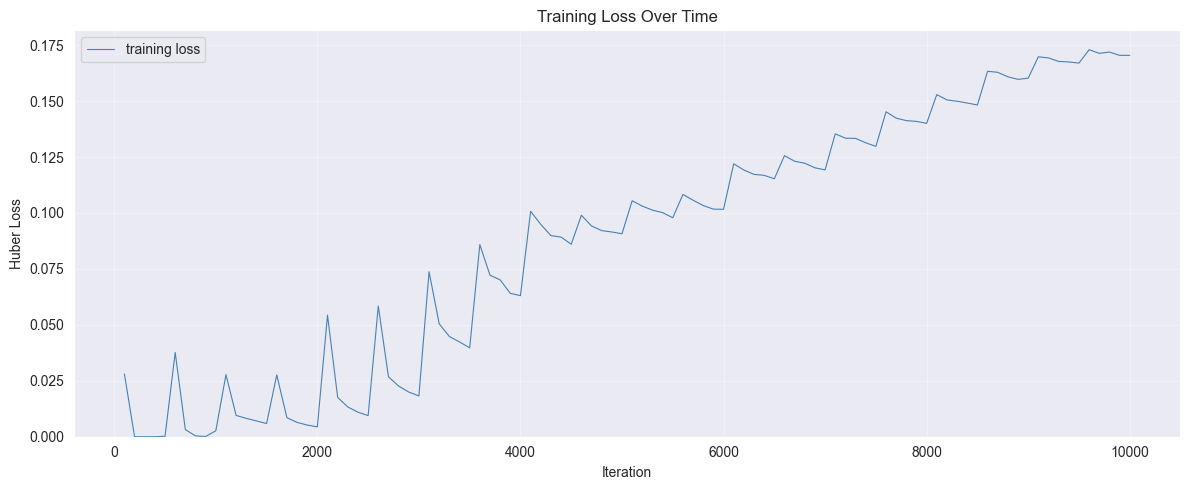

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(train_iters, train_losses, linewidth=0.8, color='steelblue', label='training loss')
plt.title('Training Loss Over Time')
plt.xlabel('Iteration')
plt.ylabel('Huber Loss')
plt.ylim(bottom=0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

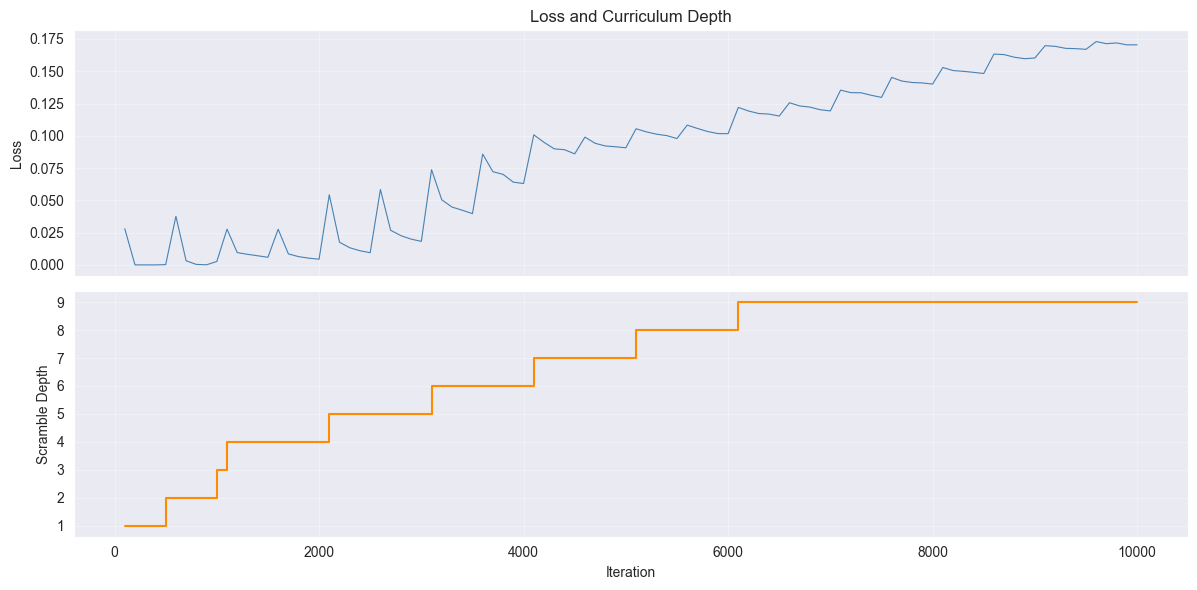

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(train_iters, train_losses, linewidth=0.8, color='steelblue')
ax1.set_ylabel('Loss')
ax1.set_title('Loss and Curriculum Depth')
ax1.grid(True, alpha=0.3)

ax2.step(train_iters, train_depths, where='post', color='darkorange', linewidth=1.5)
ax2.set_ylabel('Scramble Depth')
ax2.set_xlabel('Iteration')
ax2.set_yticks(sorted(set(train_depths)))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

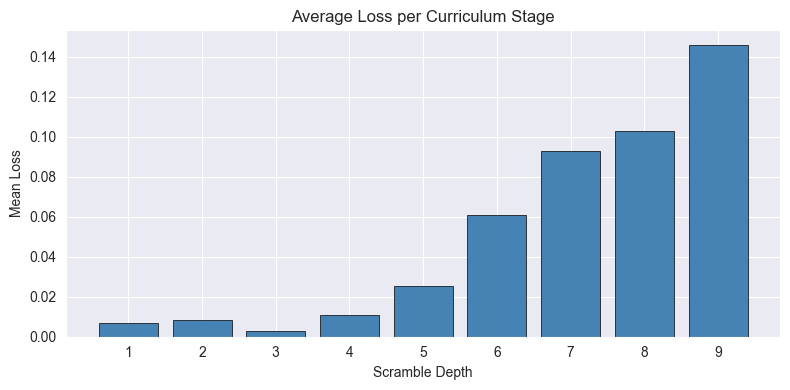

In [9]:
# average loss for each curriculum depth
depth_loss = {}
for d, l in zip(train_depths, train_losses):
    if d not in depth_loss:
        depth_loss[d] = []
    depth_loss[d].append(l)

sorted_depths = sorted(depth_loss.keys())
avg_losses    = [sum(depth_loss[d]) / len(depth_loss[d]) for d in sorted_depths]

plt.figure(figsize=(8, 4))
plt.bar(sorted_depths, avg_losses, color='steelblue', edgecolor='black', linewidth=0.5)
plt.title('Average Loss per Curriculum Stage')
plt.xlabel('Scramble Depth')
plt.ylabel('Mean Loss')
plt.xticks(sorted_depths)
plt.tight_layout()
plt.show()

In [10]:
# just print the last few evals as text
for i, it in enumerate(eval_iters[-5:]):
    idx = len(eval_iters) - 5 + i
    if idx < 0:
        continue
    print(f'iter {it}: {eval_data[idx]}')

iter 6000: {1: 100.0, 3: 100.0, 5: 100.0, 7: 94.0, 8: 96.0, 9: 88.0, 11: 72.0}
iter 7000: {1: 100.0, 3: 100.0, 5: 100.0, 7: 100.0, 9: 78.0, 11: 70.0}
iter 8000: {1: 100.0, 3: 100.0, 5: 100.0, 7: 90.0, 9: 82.0, 11: 64.0}
iter 9000: {1: 100.0, 3: 100.0, 5: 100.0, 7: 94.0, 9: 78.0, 11: 74.0}
iter 10000: {1: 100.0, 3: 100.0, 5: 100.0, 7: 94.0, 9: 78.0, 11: 68.0}


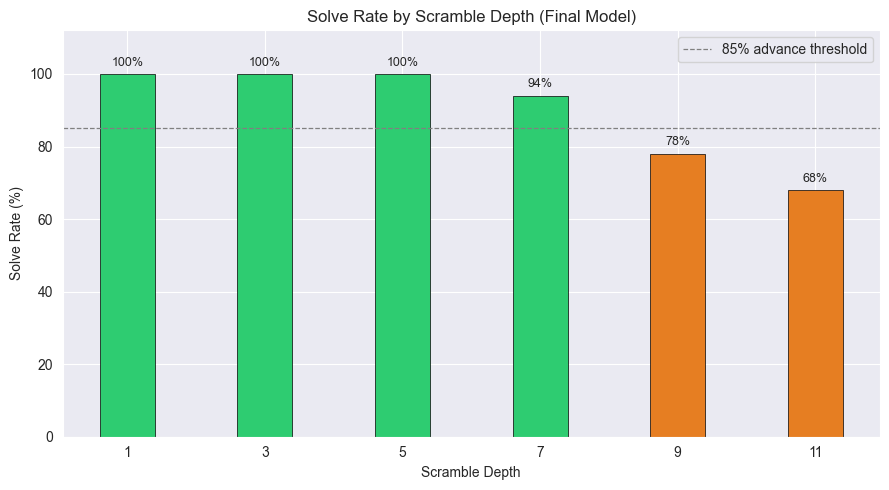

In [11]:
# bar chart of the solve rate for the final model
latest = eval_data[-1]
test_depths = sorted(latest.keys())
solve_rates = [latest[d] for d in test_depths]

bar_colors = []
for r in solve_rates:
    if r >= 80:
        bar_colors.append('#2ecc71')
    elif r >= 50:
        bar_colors.append('#e67e22')
    else:
        bar_colors.append('#e74c3c')

plt.figure(figsize=(9, 5))
bars = plt.bar(test_depths, solve_rates, color=bar_colors, edgecolor='black', linewidth=0.5)
plt.axhline(y=85, linestyle='--', color='gray', linewidth=0.9, label='85% advance threshold')
plt.title('Solve Rate by Scramble Depth (Final Model)')
plt.xlabel('Scramble Depth')
plt.ylabel('Solve Rate (%)')
plt.ylim(0, 112)
plt.xticks(test_depths)
for bar, val in zip(bars, solve_rates):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{val:.0f}%', ha='center', va='bottom', fontsize=9)
plt.legend()
plt.tight_layout()
plt.show()

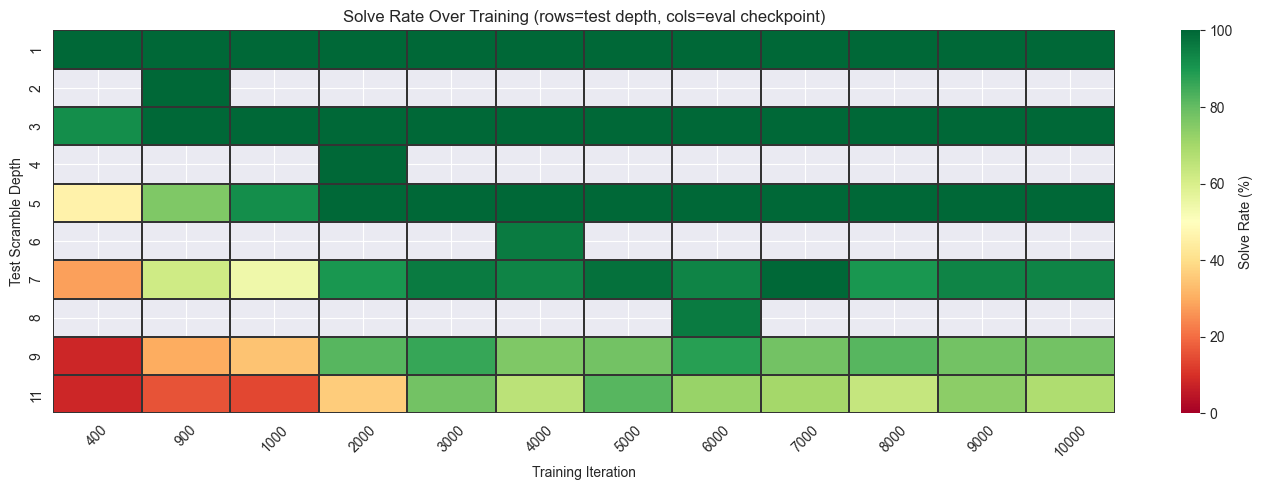

In [12]:
# heatmap of solve rate over time (rows = test depth, cols = eval point)
all_depths = set()
for r in eval_data:
    for d in r:
        all_depths.add(d)
all_depths = sorted(all_depths)

matrix = []
for d in all_depths:
    row = []
    for r in eval_data:
        row.append(r.get(d, float('nan')))
    matrix.append(row)

df_hm = pd.DataFrame(matrix, index=all_depths, columns=eval_iters)

plt.figure(figsize=(14, 5))
sns.heatmap(df_hm, cmap='RdYlGn', vmin=0, vmax=100,
            cbar_kws={'label': 'Solve Rate (%)'},
            linewidths=0.2, linecolor='#333')
plt.title('Solve Rate Over Training (rows=test depth, cols=eval checkpoint)')
plt.xlabel('Training Iteration')
plt.ylabel('Test Scramble Depth')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Drawing the cube

Helper that draws the 2x2 cube unfolded into a cross so all 6 faces show at once.

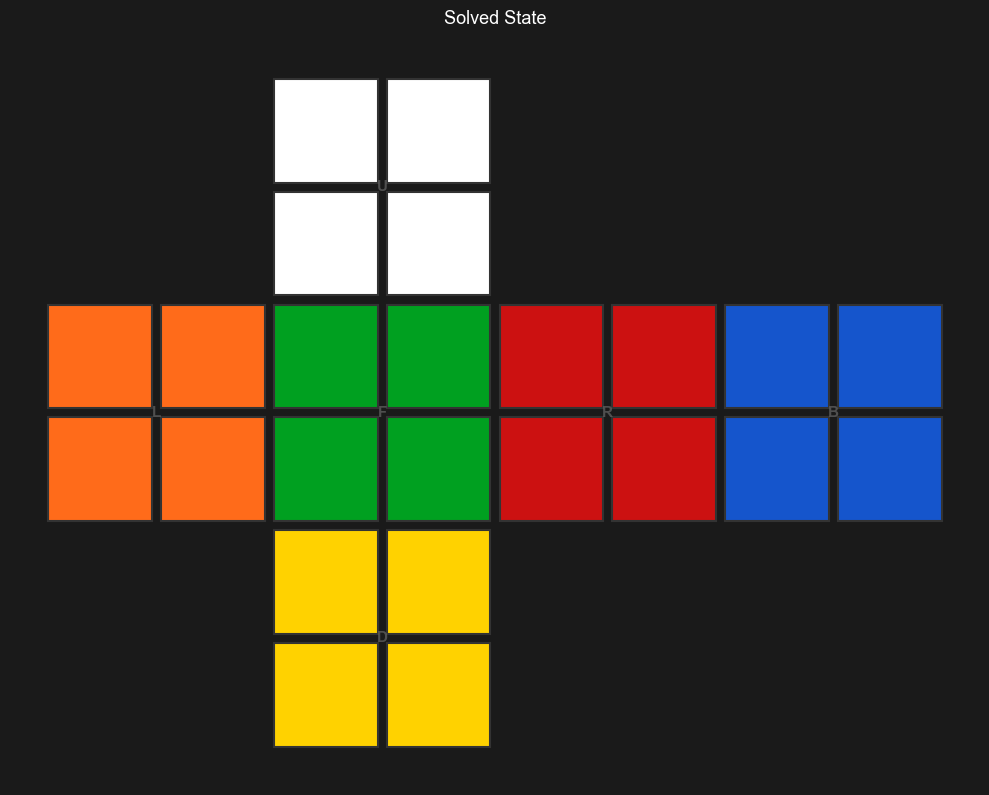

In [13]:
STICKER_COLORS = {
    0: 'white',
    1: '#ffd200',
    2: '#ff6b1a',
    3: '#cc1111',
    4: '#00a020',
    5: '#1555cc'
}
FACE_LABELS  = ['U', 'D', 'L', 'R', 'F', 'B']
FACE_OFFSETS = {
    0: (2, 4),
    1: (2, 0),
    2: (0, 2),
    3: (4, 2),
    4: (2, 2),
    5: (6, 2),
}

def draw_cube(state, title=''):
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_aspect('equal')
    ax.set_xlim(-0.3, 8.3)
    ax.set_ylim(-0.3, 6.3)
    ax.axis('off')
    ax.set_facecolor('#1a1a1a')
    fig.patch.set_facecolor('#1a1a1a')
    for face_idx in range(6):
        ox, oy = FACE_OFFSETS[face_idx]
        for r in range(2):
            for c in range(2):
                color = STICKER_COLORS[state[face_idx][r][c]]
                x = ox + c
                y = oy + (1 - r)
                rect = patches.Rectangle((x+0.04, y+0.04), 0.92, 0.92,
                                          facecolor=color, edgecolor='#333', linewidth=1.5)
                ax.add_patch(rect)
        ax.text(ox+1, oy+1, FACE_LABELS[face_idx], ha='center', va='center',
                fontsize=11, fontweight='bold', color='#666', alpha=0.7)
    if title:
        ax.set_title(title, color='white', fontsize=13, pad=12)
    plt.tight_layout()
    plt.show()

solved_state = [[[i, i], [i, i]] for i in range(6)]
draw_cube(solved_state, 'Solved State')

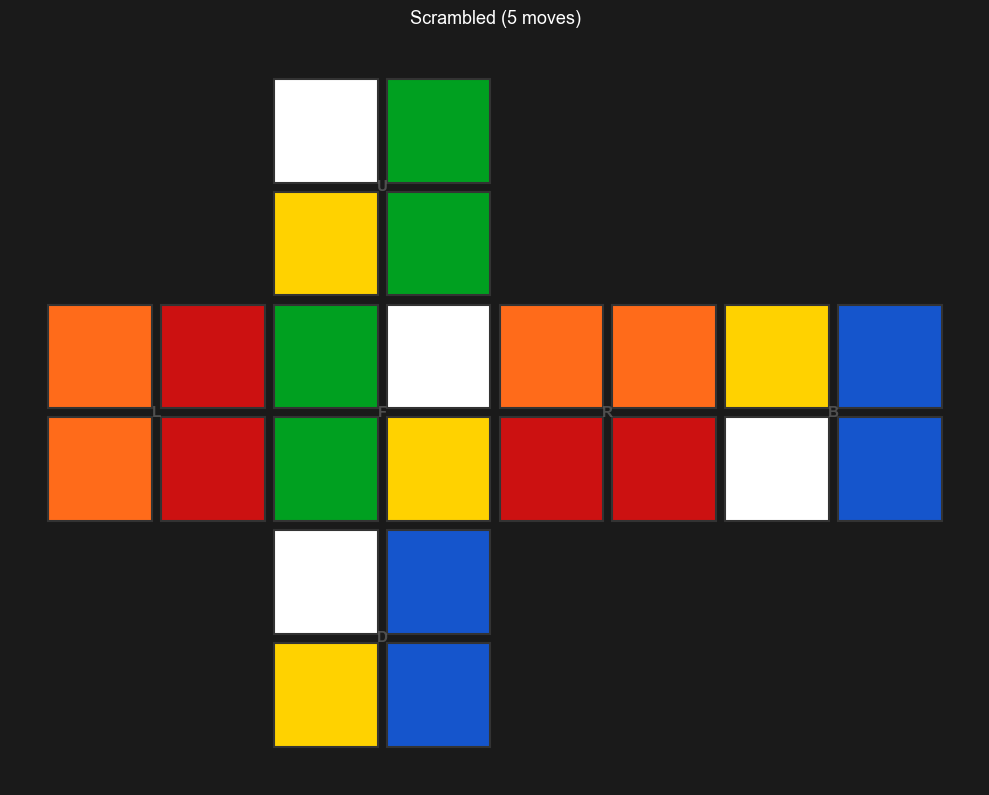

In [14]:
c = Cube()
c.scramble(5)
draw_cube(c.state.tolist(), 'Scrambled (5 moves)')

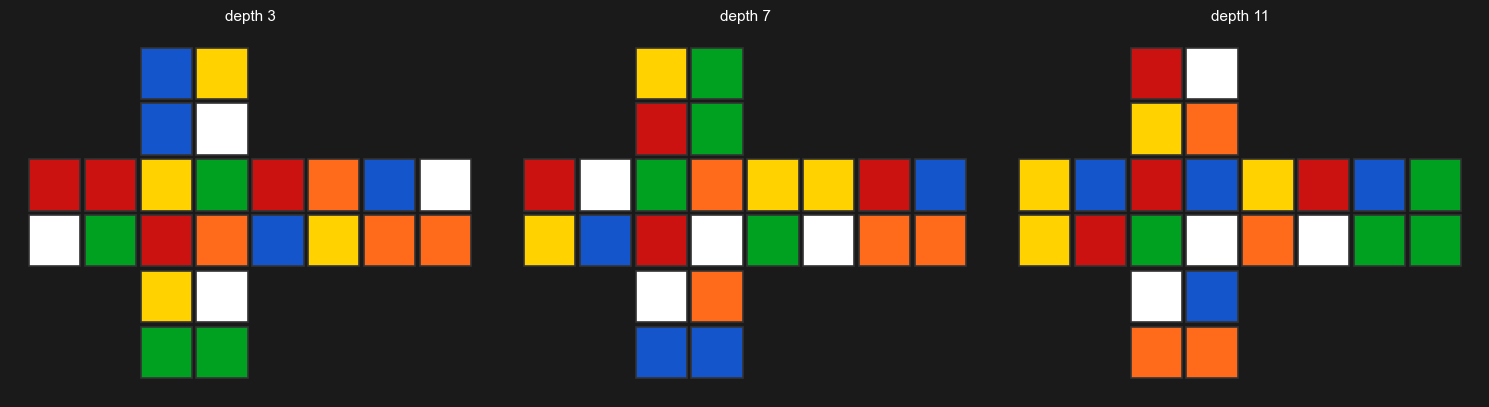

In [15]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#1a1a1a')

# depth 3
ax1.set_aspect('equal'); ax1.set_xlim(-0.3,8.3); ax1.set_ylim(-0.3,6.3)
ax1.axis('off'); ax1.set_facecolor('#1a1a1a')
cube1 = Cube(); cube1.scramble(3); state1 = cube1.state.tolist()
for face_idx in range(6):
    ox, oy = FACE_OFFSETS[face_idx]
    for r in range(2):
        for c in range(2):
            color = STICKER_COLORS[state1[face_idx][r][c]]
            rect = patches.Rectangle((ox+c+0.04, oy+(1-r)+0.04), 0.92, 0.92,
                                      facecolor=color, edgecolor='#333', linewidth=1.2)
            ax1.add_patch(rect)
ax1.set_title('depth 3', color='white', fontsize=11)

# depth 7
ax2.set_aspect('equal'); ax2.set_xlim(-0.3,8.3); ax2.set_ylim(-0.3,6.3)
ax2.axis('off'); ax2.set_facecolor('#1a1a1a')
cube2 = Cube(); cube2.scramble(7); state2 = cube2.state.tolist()
for face_idx in range(6):
    ox, oy = FACE_OFFSETS[face_idx]
    for r in range(2):
        for c in range(2):
            color = STICKER_COLORS[state2[face_idx][r][c]]
            rect = patches.Rectangle((ox+c+0.04, oy+(1-r)+0.04), 0.92, 0.92,
                                      facecolor=color, edgecolor='#333', linewidth=1.2)
            ax2.add_patch(rect)
ax2.set_title('depth 7', color='white', fontsize=11)

# depth 11
ax3.set_aspect('equal'); ax3.set_xlim(-0.3,8.3); ax3.set_ylim(-0.3,6.3)
ax3.axis('off'); ax3.set_facecolor('#1a1a1a')
cube3 = Cube(); cube3.scramble(11); state3 = cube3.state.tolist()
for face_idx in range(6):
    ox, oy = FACE_OFFSETS[face_idx]
    for r in range(2):
        for c in range(2):
            color = STICKER_COLORS[state3[face_idx][r][c]]
            rect = patches.Rectangle((ox+c+0.04, oy+(1-r)+0.04), 0.92, 0.92,
                                      facecolor=color, edgecolor='#333', linewidth=1.2)
            ax3.add_patch(rect)
ax3.set_title('depth 11', color='white', fontsize=11)

plt.tight_layout()
plt.show()

## Model architecture

The network layers and the parameter count.

In [16]:
total_params = sum(p.numel() for p in model.parameters())
print(model)
print()
print(f'total parameters: {total_params:,}')
print()
print(f'{"layer":<35} {"params":>10}')
print('-' * 47)
for name, param in model.named_parameters():
    print(f'{name:<35} {param.numel():>10,}')

ValueNetwork(
  (embed): Sequential(
    (0): Linear(in_features=144, out_features=768, bias=True)
    (1): ReLU()
  )
  (res): Sequential(
    (0): ResBlock(
      (fc1): Linear(in_features=768, out_features=768, bias=True)
      (fc2): Linear(in_features=768, out_features=768, bias=True)
    )
    (1): ResBlock(
      (fc1): Linear(in_features=768, out_features=768, bias=True)
      (fc2): Linear(in_features=768, out_features=768, bias=True)
    )
    (2): ResBlock(
      (fc1): Linear(in_features=768, out_features=768, bias=True)
      (fc2): Linear(in_features=768, out_features=768, bias=True)
    )
    (3): ResBlock(
      (fc1): Linear(in_features=768, out_features=768, bias=True)
      (fc2): Linear(in_features=768, out_features=768, bias=True)
    )
  )
  (head): Linear(in_features=768, out_features=18, bias=True)
)

total parameters: 4,849,938

layer                                   params
-----------------------------------------------
embed.0.weight                         

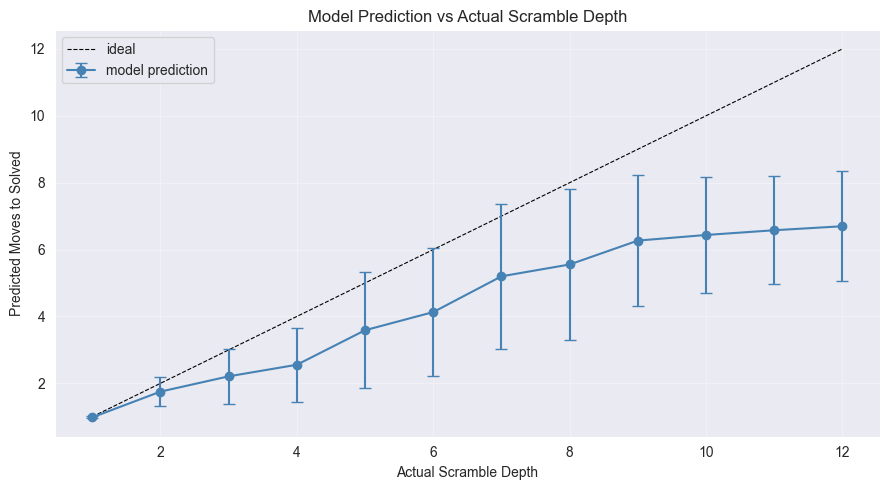

In [17]:
# check what distance the model predicts for cubes at each scramble depth.
# the network outputs 18 Q values, the best one (max) is about -(moves left),
# so -max gives the predicted number of moves to solve.
model.eval()
test_depths = list(range(1, 13))
avg_preds   = []
std_preds   = []

for depth in test_depths:
    preds = []
    for _ in range(50):
        c = Cube()
        c.scramble(depth)
        vec = torch.tensor(c.get_state_vector(), dtype=torch.float32).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            p = -model(vec).max().item()
        preds.append(p)
    avg_preds.append(sum(preds) / len(preds))
    std_preds.append(float(np.std(preds)))

plt.figure(figsize=(9, 5))
plt.plot(test_depths, test_depths, 'k--', linewidth=0.8, label='ideal')
plt.errorbar(test_depths, avg_preds, yerr=std_preds, fmt='o-', color='steelblue',
             linewidth=1.5, capsize=4, label='model prediction')
plt.xlabel('Actual Scramble Depth')
plt.ylabel('Predicted Moves to Solved')
plt.title('Model Prediction vs Actual Scramble Depth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion

The model solves easy scrambles really well - up to around 7 moves it's basically 100%. For the harder ones (9-12 moves) the solve rate drops off, which makes sense since those are close to the 2x2 god's number which is 11.

The curriculum helped a lot. Starting at depth 1 and only going harder once the model was good enough made training way more stable. You can see in the loss plot that every time the depth goes up the loss jumps and then comes back down.

The target network and the discount factor were needed to stop the Q values from blowing up, which kept happening before we added them.

One thing we noticed is the predicted moves for an 11 move scramble is usually less than 11. That's because random scrambles often undo themselves a bit, so the real shortest solution is shorter than the scramble length.

The biggest limitation is the search budget at eval time. The deeper cubes need way more nodes to solve, so with a bigger node budget the hard depths would probably do better.